# Does the model represent *illegality* as distinct from *harmfulness*?

**What this notebook does, in one paragraph.** We show a small open model 250 short scenarios (plus 60 plain legal-harmless anchors and 61 negated rows that are never trained on, only scored) arranged as a 2×2: illegal-and-harmful, illegal-but-harmless, legal-but-harmful, legal-and-harmless, four per topic so topics are matched. We record the model's internal state for each sentence and train the simplest possible detector, a linear probe, to read off *legal vs illegal*. The catch is that on the two "easy" corners legal is the same thing as not-harmful, so a probe trained there cannot tell legality from harm. So we train the legality probe **only on harmful sentences** and test it **only on harmless sentences from topics it never saw**, and the reverse; if it still works, legality is decodable independently of harm. We do the same for harm, measure the angle between the two directions, compare with just asking the model, and check what happens when legality words are removed.

**How to use it.** Run top to bottom. Every code cell has a note above it. Settings are in one cell (2). The clock starts at the ⏱ line; the dataset hand-check (cell 5) is the first clocked task and the one that decides whether the project is real.

**Where instructions live.** Step-by-step with checkboxes: the vault note *MATS 12 - Run Sheet (legality probe)*. The design in one page and the decisions that are yours: `journal/design-questions-legality-probe.md`. The hand-check columns: `data/SCENARIOS_COLUMNS.md`.

**Prior work this must answer in the first paragraph:** Sadhu et al. 2026 (arXiv 2608.16852), Schwarz 2026 (2607.13075); method precedents Baez et al. 2026 (2607.07003), Shah et al. 2025 (2507.21141), Boxo et al. 2025 (2509.21344). This project adds the legality × harm factorial with conditional generalisation across strata, the angle between factorial directions, and an intervention.

### 1 · GPU check
**Runtime → Change runtime type → GPU.** A free T4 is enough; this project is one forward pass per sentence.

In [1]:
import subprocess
print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"], capture_output=True, text=True).stdout.strip() or "NO GPU — Runtime → Change runtime type → GPU")

Tesla T4, 15360 MiB


### 2 · Settings — the only cell you edit
- `MODEL`: Qwen3.5-4B first; 9B if you have an L4/A100 and time.
- `RUN`: a name for this session's files (the prompted condition is saved as `<RUN>_prompted`).
- `VAL_TOPICS` / `TEST_TOPICS`: how many of the 60 topics are held out for choosing the layer and for the final score. Do not change after seeing results.
- `DRIVE_DIR`: where results persist on your Google Drive.

In [2]:
MODEL       = "Qwen/Qwen3.5-4B"
RUN         = "lp_4b"
VAL_TOPICS  = 15
TEST_TOPICS = 15
DRIVE_DIR   = "/content/drive/MyDrive/mats12_runs"


### 3 · Get the code and connect Drive (uncounted)
Clones the private repo (needs `GITHUB_TOKEN` in Colab Secrets), installs packages, moves `data/`, `figures/`, `journal/` onto Drive.

In [3]:
import os, subprocess
from google.colab import drive, userdata
try:
    drive.mount("/content/drive", timeout_ms=90000)   # a Google sign-in popup appears; if it is blocked or ignored, we fall back to local disk
except Exception as e:
    DRIVE_DIR = "/content/mats12_runs"
    print("Drive not mounted (" + str(e)[:80] + "). Using local disk instead: results will NOT survive this machine. Re-run this cell later and accept the popup to persist to Drive.")
os.makedirs(DRIVE_DIR, exist_ok=True)
from getpass import getpass
token = None
for name in ("GITHUB_TOKEN", "colab-mats12"):     # Colab Secrets panel (key icon): either name, "Notebook access" ON
    try:
        token = userdata.get(name)
        if token: break
    except Exception:
        pass
if not token:
    print("No GITHUB_TOKEN found in Colab Secrets. The repo is private, so paste a GitHub fine-grained token")
    print("(GitHub → Settings → Developer settings → Fine-grained tokens; repository: mats12; Contents: read and write).")
    token = getpass("GitHub token: ").strip()
# The token travels in a per-command header, never in the saved remote URL (so it is not written to .git/config).
import base64
AUTH = ["-c", "http.extraheader=AUTHORIZATION: basic " + base64.b64encode(f"x-access-token:{token}".encode()).decode()]
os.environ["MATS12_GIT_AUTH"] = AUTH[1]
if not os.path.exists("/content/mats12"):
    r = subprocess.run(["git", *AUTH, "clone", "-q", "https://github.com/martinherje/mats12.git", "/content/mats12"], capture_output=True, text=True)
else:
    # The Drive links make git see local changes; autostash carries them across the pull. If that still fails,
    # back up every changed file to Drive, reset, and pull clean — nothing is lost, and the backup path is printed.
    R = "/content/mats12"
    r = subprocess.run(["git", *AUTH, "-C", R, "pull", "--rebase", "--autostash", "-q"], capture_output=True, text=True)
    if r.returncode != 0:
        import shutil, time
        bk = f"{DRIVE_DIR}/backup_{time.strftime('%Y%m%d_%H%M%S')}"
        changed = subprocess.run(["git", "-C", R, "status", "--porcelain"], capture_output=True, text=True).stdout.split("\n")
        for line in changed:
            f = line[3:].strip()
            if f and os.path.isfile(os.path.join(R, f)):
                os.makedirs(os.path.dirname(os.path.join(bk, f)), exist_ok=True); shutil.copy2(os.path.join(R, f), os.path.join(bk, f))
        subprocess.run(["git", "-C", R, "rebase", "--abort"], capture_output=True)
        subprocess.run(["git", "-C", R, "reset", "--hard", "-q"], check=True)
        r = subprocess.run(["git", *AUTH, "-C", R, "pull", "-q"], capture_output=True, text=True)
        print(f"local changes were backed up to {bk} and the repo reset before pulling")
if r.returncode != 0:
    raise SystemExit("git failed: " + r.stderr.replace(token, "<token>").strip() + "\nCheck the token has access to martinherje/mats12 (Contents: read).")
%cd /content/mats12
!git log --oneline -1
!bash scripts/colab_setup.sh "$DRIVE_DIR"

Mounted at /content/drive
/content/mats12
d920864 (HEAD -> main, origin/main, origin/HEAD) Revise expectations for legality and harm probes
data/raw and data/processed -> /content/drive/MyDrive/mats12_runs (linked); journal and figures restored from Drive if present
torch 2.11.0+cu128 | transformers 5.16.1 | cuda True | Tesla T4 15 GB cap (7, 5)


### 4 · Load the model once (uncounted)
Expect 32 layers, width 2560, memory well under the card's total.

In [4]:
!python scripts/gpu_smoke.py --model $MODEL

torch 2.11.0+cu128 · device cuda · dtype torch.float16
gpu: Tesla T4 14.6 GB
config.json: 100% 3.16k/3.16k [00:00<00:00, 9.01MB/s]
tokenizer_config.json: 100% 16.7k/16.7k [00:00<00:00, 25.0MB/s]
vocab.json: 100% 6.72M/6.72M [00:00<00:00, 58.3MB/s]
merges.txt: 100% 3.35M/3.35M [00:00<00:00, 95.4MB/s]

tokenizer.json: downloading bytes:   0% 0.00/12.8M [00:00<?, ?B/s]
tokenizer.json: downloading bytes: 100% 5.68M/5.68M [00:00<00:00, 11.0MB/s,  561kB/s  ]
tokenizer.json: reconstructing file: 100% 12.8M/12.8M [00:00<00:00, 24.7MB/s, 1.27MB/s  ]
chat_template.jinja: 100% 7.76k/7.76k [00:00<00:00, 25.2MB/s]
model.safetensors.index.json: 100% 76.2k/76.2k [00:00<00:00, 171MB/s]
Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0% 0/2 [00:00<?, ?it/s]
Reconstructing (incomplete total...):   0% 0.00/5.33G [00:00<?, ?B/s]         
Reconstructing (incomplete total...):   3% 256M/9.32G [00:01<00:48, 185MB/s,  405kB/s  ]  
Reconstructing (incomplete 

## ⏱ The clock starts here
Answer `journal/design-questions-legality-probe.md` (Files panel → `mats12/journal`), copy the answers into `journal/highlights.md` with the date, start Toggl.

### 5 · The dataset, and the hand-check that decides whether the project is real
`data/scenarios.csv` holds 240 candidate sentences: 60 topics × 4 quadrants, US law, written by Claude on 9 Sep and **not yet checked by anyone**. This cell validates the file and shows a sample. Your job, on the clock: open the CSV in the Files panel (double-click), read every sentence (off-diagonal quadrants first: `illegal_harmless`, `legal_harmful`, they are the test set), and for each row set `hand_checked=1`; fix `legal` / `harmful` where you disagree and set `relabelled=1` (and fix `quadrant` to match); set `borderline=1` where a competent lawyer could argue either way on the facts given; set `exclude=1` where the label depends on facts the sentence does not give. Save, re-run this cell until it says OK. Column meanings: `data/SCENARIOS_COLUMNS.md`. The write-up reports how many you read, relabelled and excluded.

In [5]:
import pandas as pd
!python scripts/validate_scenarios.py data/scenarios.csv
df = pd.read_csv("data/scenarios.csv")
pd.set_option("display.max_colwidth", 120)
print(df[["id", "quadrant", "topic", "borderline", "text"]].sample(12, random_state=0).to_string(index=False))
print("\nEdit data/scenarios.csv in the Files panel (double-click), then re-run this cell to validate.")

sets: {'main': np.int64(250), 'negated': np.int64(61), 'simple': np.int64(60)} — only set=main enters the probe design; simple and negated rows are scored once as checks
scenarios.csv: 250 rows · jurisdiction=['US']
borderline_legal: 66   borderline_harm: 46
per quadrant (core / borderline):
  illegal_harmful      62   core=  53  borderline=   9
  illegal_harmless     65   core=  26  borderline=  39
  legal_harmful        62   core=  24  borderline=  38
  legal_harmless       61   core=  58  borderline=   3
hand_checked: 100% (250/250) · relabelled among checked: 2%
excluded (indeterminate) rows: 6 — dropped from the probe evaluation, reported in the write-up
topics with all 4 rows still usable: 56/60
topics: 60 · text length words: min 4, median 13, max 22
OK
  id         quadrant         topic  borderline                                                                                                text
s142 illegal_harmless     insurance           0                     You describe 

### 6 · Record the model's internal state, in two conditions
**A. Bare sentence:** one forward pass per scenario, the state at the last token. **B. Prompted:** the sentence inside the exact question the just-ask baseline uses ("Under the law of the United States, is the following action illegal? Answer with exactly one word: Yes or No."), the state at the token before the model answers. B is the headline condition (the model has been asked the question the probe answers); A is the "unprompted representation" secondary result. Look for "acts (N, 33, 2560)" twice, where N is the number of rows in the CSV.


In [6]:
!python scripts/extract_activations.py --model $MODEL --scenarios data/scenarios.csv --run $RUN --batch-size 16
!python scripts/extract_activations.py --model $MODEL --scenarios data/scenarios.csv --run {RUN}_prompted --batch-size 16 --template chat --generation-prompt --enable-thinking off --question legal


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files: 100% 2/2 [00:00<00:00, 992.62it/s]
Download complete: :           |  0.00B            
Download complete: :           |  0.00B            
Reconstruction complete: |          |  0.00B /  0.00B            
Loading weights: 100% 426/426 [00:33<00:00, 12.65it/s]
Qwen/Qwen3.5-4B on cuda/torch.float16 · 371 scenarios · pool=last · template=raw
extract: 100% 24/24 [00:15<00:00,  1.60it/s]
wrote data/processed/acts_lp_4b.npz · acts (371, 33, 2560) (N, layers+1, d) · truncated=0
HAND-CHECK: open the .json manifest and confirm model/pool/template are what you intended before training anything on this.
Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files: 100% 2/2 [00:00<00:00, 457.82it/s]
Download complete: :           |  0.00B            
Reconstruction complete: |          |  0.00B /  0.00B            
Download complete: :           |  0.00B            

### 7 · The test that can actually answer the question: conditional generalisation, held-out topics (~45 min)
Training on the easy corners cannot separate "legality" from "not-harm": on those rows they are the same label. So the probe for *legal* is trained **inside one harm stratum** (legal-harmful vs illegal-harmful) and tested **on the other stratum** (legal-harmless vs illegal-harmless), on **topics it never saw**. Then the reverse. Then the symmetric pair for *harmful*. Layer and regularisation are chosen on validation AUROC only; the test topics are scored once; the interval is a topic-block bootstrap; a null repeats the whole selection 100 times on labels shuffled within each topic and stratum, and the write-up says "beat N of 100 shuffles".

The same script estimates the two *factorial* directions on training topics, reports the angle between them at every layer with a label-swap null band, scores the legality direction within each harm stratum on held-out topics, and again with the top 1–3 harm components removed.

Runs the four designs on conditions A and B, and the main design on C (for its cosine curve). Read the "TEST cross-stratum acc … beat N/100" lines.

In [7]:
DESIGNS = [("legal", "harmful", "L_h2nh"), ("legal", "harmless", "L_nh2h"), ("harmful", "illegal", "H_i2l"), ("harmful", "legal", "H_l2i")]
for cond in [RUN, f"{RUN}_prompted"]:
    for target, stratum, tag in DESIGNS:
        print(f"\n################ {cond} · {tag}: {target} probe trained inside {stratum}, tested on the other stratum ################")
        !python scripts/probe_eval.py --run {cond} --target {target} --train-stratum {stratum} --tag {tag} --val-topics $VAL_TOPICS --test-topics $TEST_TOPICS



################ lp_4b · L_h2nh: legal probe trained inside harmful, tested on the other stratum ################
run=lp_4b · target=legal · train inside harmful=1 · rows kept 244 · topics train/val/test 30/15/15
train n=61 · validation cross-stratum n=30 · test in-stratum n=30 cross-stratum n=30

=== headline (layer and C chosen on validation AUROC, test topics scored once, cross-stratum) ===
layer 25 · C 1.0 · validation cross-stratum AUROC 0.711
TEST cross-stratum acc 0.700  CI95 0.53–0.83  AUROC 0.742  (in-stratum test acc 0.900)
null (labels shuffled within topic×stratum, same selection, 100 shuffles): acc mean 0.505, p95 0.600, max 0.633 · beat 100/100 on accuracy, 100/100 on AUROC
cos(d_legal, d_harm) at layer 25: -0.091 (null band -0.26..+0.28); curve over layers saved
d_legal AUROC on test topics — within harmful 0.871, within harmless 0.676; d_legal predicting harm 0.502
d_legal with harm removed (top-1/2/3 harm components) — within harmful: 0.862, 0.942, 0.973 · within harm

### 8 · The summary table, and the no-legality-words rerun
Collects the eight headline numbers. Then reruns the main design with every row containing explicit legality vocabulary dropped (after the 9 Sep rewrite almost no row names a rule, so this should change little), so you can see how much of the signal is the words. If the number barely moves, the signal is not lexical; if it collapses, say so.

In [8]:
import json, pandas as pd
rows = []
for cond in [RUN, f"{RUN}_prompted"]:
    for target, stratum, tag in DESIGNS:
        r = json.load(open(f"data/processed/probeeval_{cond}_{tag}.json")); pn = r["perm_null"]; fa = r["factorial"]
        rows.append({"condition": "prompted" if cond.endswith("_prompted") else "bare", "probe": target, "trained inside": stratum, "layer": r["layer"], "C": r["C"],
                     "test acc": r["test_cross_acc"], "ci95": "%.2f–%.2f" % tuple(r["test_cross_acc_ci95"]), "test AUROC": r["test_cross_auroc"],
                     "beat shuffles": f"{pn['shuffles_beaten_acc']}/{pn['n']}", "null p95": pn["acc_p95"], "cos(dL,dH)": fa["cos_dlegal_dharm"],
                     "dL within harmless": fa["dlegal_auroc_within_harmless"], "dL−harm(top3) within harmless": fa["dlegal_minus_harm_top3_auroc_within_harmless"],
                     "length only": r.get("length_only_test_auroc"), **{f"check {k}": v[[x for x in v if x.startswith("frac_predicted_")][0]] for k, v in (r.get("extra_sets") or {}).items()}})
print(pd.DataFrame(rows).round(3).to_string(index=False))
!python scripts/results_table.py --run $RUN > /dev/null && echo "markdown table written to journal/results.md"
print("\n--- main design with legality-vocabulary rows dropped ---")
!python scripts/probe_eval.py --run $RUN --target legal --train-stratum harmful --tag L_h2nh_nocue --drop-cue-rows --val-topics $VAL_TOPICS --test-topics $TEST_TOPICS

condition   probe trained inside  layer     C  test acc      ci95  test AUROC beat shuffles  null p95  cos(dL,dH)  dL within harmless  dL−harm(top3) within harmless  length only  check negated  check simple
     bare   legal        harmful     25  1.00     0.700 0.53–0.83       0.742       100/100     0.600      -0.091               0.676                          0.707        0.600          1.000         0.550
     bare   legal       harmless     32  0.01     0.667 0.57–0.80       0.711        93/100     0.667      -0.110               0.698                          0.680        0.793          0.902         0.933
     bare harmful        illegal     14  0.01     0.767 0.63–0.90       0.947        98/100     0.667      -0.176               0.658                          0.667        0.569          0.000         0.000
     bare harmful          legal      3 10.00     0.800 0.67–0.90       0.827       100/100     0.633      -0.002               0.591                          0.631        

### 8b · The results in plain language, the fair baseline, and the cosine curves
One paragraph per design with a verdict. The FAIR BASELINE line compares the probe with the model's own Yes/No judgement on the *same* held-out sentences (needs cell 9 to have run). Then the figure that carries the story: cos(d_legal, d_harm) at every layer for the bare and prompted conditions, with the label-swap null band. Inside the band means "no more aligned than chance"; well below it means the two directions point in opposite ways (illegal and harmful share an axis).



=== Condition: bare sentence ===

  A legality probe trained on harmful sentences (layer 25 chosen on validation topics), tested on harmless sentences from 15 topics it never saw:
    got 70% right (likely range 53%–83%), AUROC 0.74; shuffled labels would get up to 60%; beat 100/100 shuffles.  → CLEAR: well above what shuffled labels achieve
    Word count alone on the same test rows: AUROC 0.60 (0.5 = length carries nothing).
    Check set 'negated' (61 rows, never trained on, expected all 1): the probe calls 100% of them legal=1.
    Check set 'simple' (60 rows, never trained on, expected all 1): the probe calls 55% of them legal=1.
    The legality and harm directions sit at cosine -0.09 (0 = unrelated, ±1 = the same line).
    Within the harmless sentences of held-out topics, the legality direction sorts legal from illegal at AUROC 0.68; with the top 1/2/3 harm components removed: 0.68/0.68/0.71 (0.5 = coin flip).

  A legality probe trained on harmless sentences (layer 32 chosen 

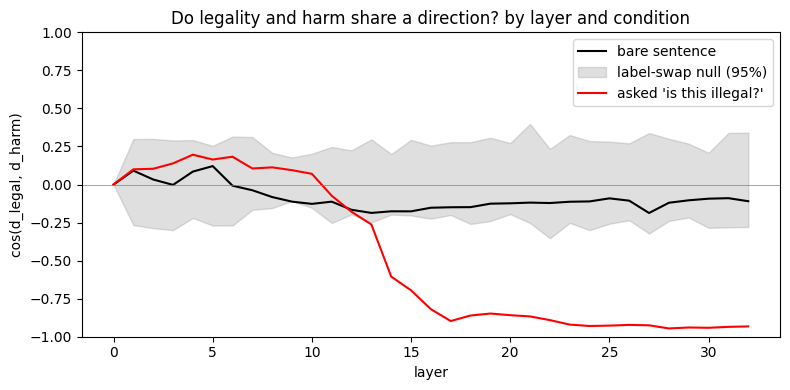

figures/probeeval_lp_4b_L_h2nh.png


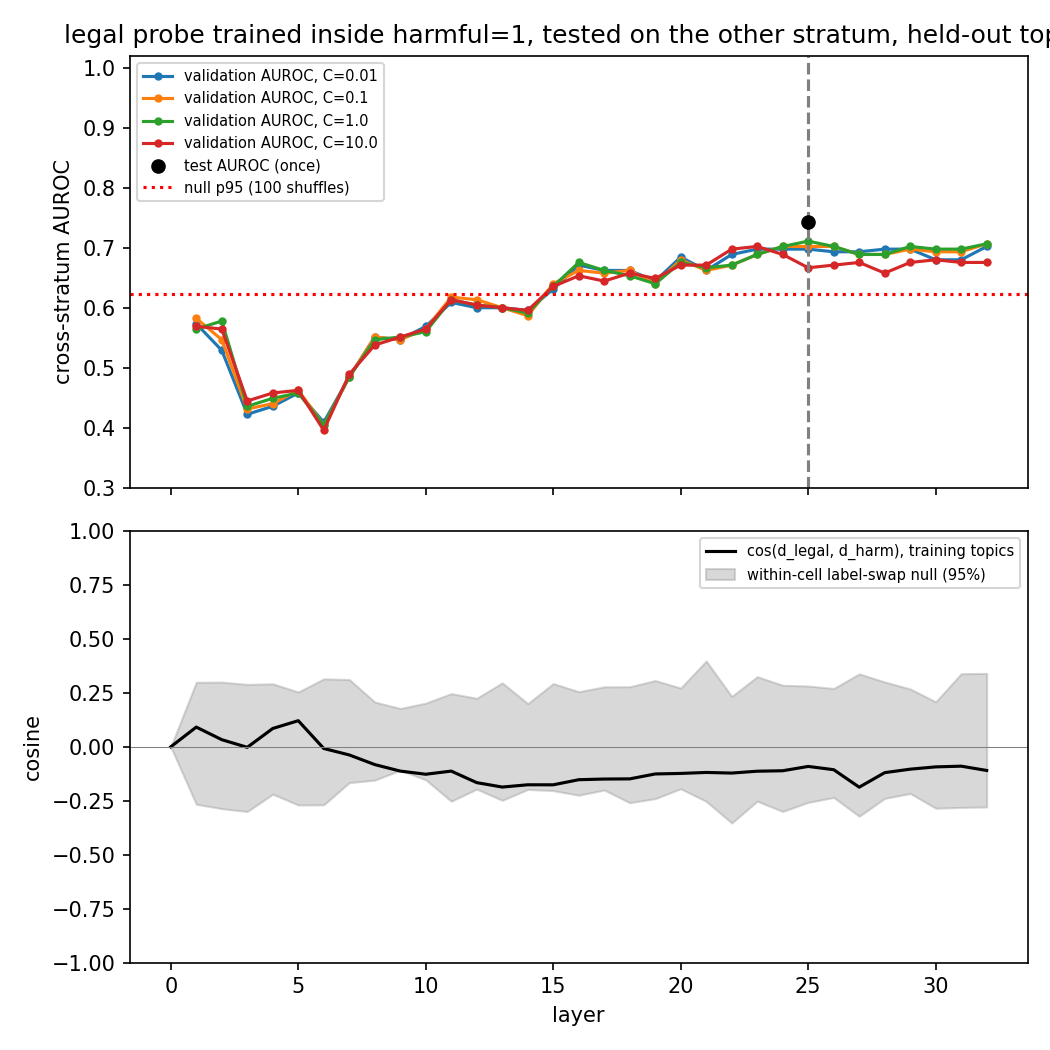

figures/probeeval_lp_4b_L_h2nh_nocue.png


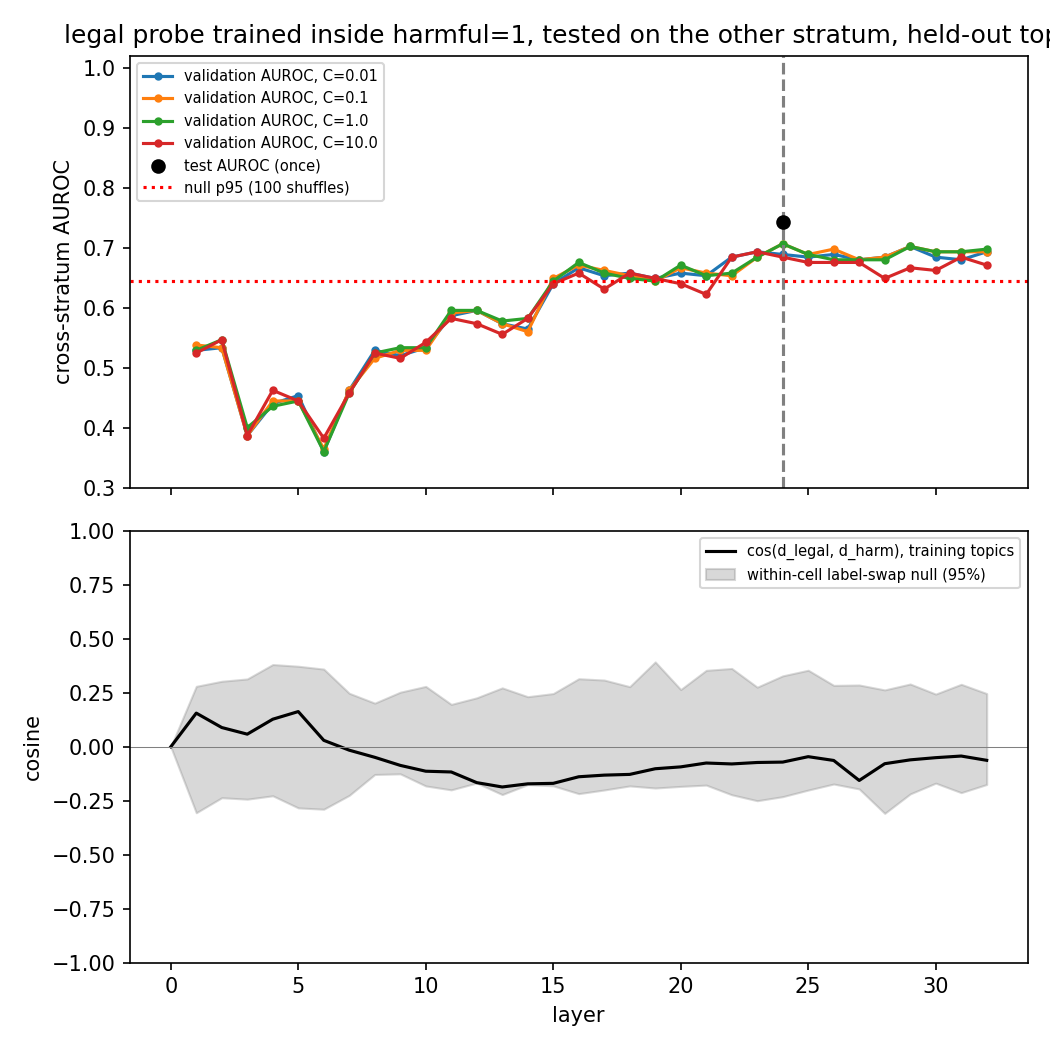

In [9]:
!python scripts/report.py --run $RUN
import json, matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
for cond, name, col in [(RUN, "bare sentence", "k"), (f"{RUN}_prompted", "asked 'is this illegal?'", "r")]:
    try:
        c = json.load(open(f"data/processed/probeeval_{cond}_L_h2nh.json"))["cosine_curve"]
        ax.plot(c["layers"], c["cos_dlegal_dharm"], color=col, label=name)
        if cond == RUN: ax.fill_between(c["layers"], c["null_lo"], c["null_hi"], color="gray", alpha=0.25, label="label-swap null (95%)")
    except FileNotFoundError: pass
ax.axhline(0, color="gray", lw=0.5); ax.set_xlabel("layer"); ax.set_ylabel("cos(d_legal, d_harm)"); ax.set_ylim(-1, 1); ax.legend(); ax.set_title("Do legality and harm share a direction? by layer and condition")
fig.tight_layout(); fig.savefig(f"figures/cosine_by_layer_{RUN}.png", dpi=150); plt.show()
from IPython.display import Image, display
import glob
for f in sorted(glob.glob(f"figures/probeeval_{RUN}_L_h2nh*.png")): print(f); display(Image(f, width=650))

### 9 · Just ask the model
The cheapest baseline and the one Nanda names first. Shows every sentence to the model and asks "Is this illegal? Yes or No", then "Is this harmful?", scores the answers per quadrant, and also records the model's Yes-minus-No logit so its graded judgement can be scored as a classifier on the same held-out rows as the probe (cell 8b prints that comparison). Invalid answers are counted separately.

In [10]:
!python scripts/ask_model.py --run $RUN --label legal --model $MODEL
!python scripts/ask_model.py --run $RUN --label harmful --model $MODEL

dropped 6 rows with exclude=1 (same rows the probe evaluation drops); 365 remain
Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files: 100% 2/2 [00:00<00:00, 851.20it/s]
Download complete: :           |  0.00B            
Download complete: :           |  0.00B            
Reconstruction complete: |          |  0.00B /  0.00B            
Loading weights: 100% 426/426 [00:34<00:00, 12.19it/s]
/content/mats12/data/raw/ask_lp_4b_legal.jsonl exists; choose a new --run
dropped 6 rows with exclude=1 (same rows the probe evaluation drops); 365 remain
Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files: 100% 2/2 [00:00<00:00, 1041.55it/s]
Download complete: :           |  0.00B            
Download complete: :           |  0.00B            
Reconstruction complete: |          |  0.00B /  0.00B            
Loading weights: 100% 426/426 [00:34<00:00, 12.29it/s]
/content/mats12/data/raw/ask_lp_4b_harmful.json

### 10 · Recompute the headline by hand, and read the probe's mistakes
Rebuilds the main design's test number from the saved activations and the saved topic split, line by line, so you can follow it; then prints the held-out sentences the probe got wrong. Are they the borderline rows? The ones with legality words? Write a paragraph in `journal/verification-log.md`.

In [11]:
import numpy as np, pandas as pd, json
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
r = json.load(open(f"data/processed/probeeval_{RUN}_L_h2nh.json")); L, C = r["layer"], r["C"]
z = np.load(f"data/processed/acts_{RUN}.npz"); acts = z["acts"].astype(np.float32); cols = {k[4:]: z[k] for k in z.files if k.startswith("col_")}
df = pd.DataFrame({k: v for k, v in cols.items()}); df["legal"] = df.legal.astype(int); df["harmful"] = df.harmful.astype(int)
if "exclude" in df: keep = df.exclude.astype(int) == 0; df, acts = df[keep].reset_index(drop=True), acts[keep.to_numpy()]
train = df.topic.isin(r["split"]["train_topics"]) & (df.harmful == 1)          # legality probe trained inside the harmful stratum
test  = df.topic.isin(r["split"]["test_topics"])  & (df.harmful == 0)          # tested on the harmless stratum, unseen topics
clf = make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=3000)).fit(acts[train.to_numpy(), L], df.legal[train])
pred = clf.predict(acts[test.to_numpy(), L]); truth = df.legal[test].to_numpy()
print(f"recomputed cross-stratum test accuracy at layer {L}, C={C}: {(pred == truth).mean():.3f}   (script reported {r['test_cross_acc']:.3f})")
wrong = df[test][pred != truth]
print(f"\n{len(wrong)} mistakes on held-out harmless-stratum sentences:")
for _, w in wrong.iterrows(): print(f"  [{w.quadrant:17s} borderline={w.borderline}] {w.text}")

recomputed cross-stratum test accuracy at layer 25, C=1.0: 0.683   (script reported 0.700)

19 mistakes on held-out harmless-stratum sentences:
  [legal_harmless    borderline=0] You file your tax return two weeks before the deadline.
  [illegal_harmless  borderline=0] You keep a pet hedgehog in your apartment in California.
  [legal_harmless    borderline=0] You take your dog for a walk in the park.
  [legal_harmless    borderline=0] You cook pasta for dinner.
  [legal_harmless    borderline=0] You repaint your living room.
  [illegal_harmless  borderline=1] You structure a deposit into two payments to avoid a paperwork form, with legitimately earned money.
  [legal_harmless    borderline=0] You check your balance at an ATM.
  [illegal_harmless  borderline=1] You water your lawn at noon in the middle of a drought emergency.
  [legal_harmless    borderline=0] You fill a glass of water from the tap.
  [legal_harmless    borderline=0] You attend a public Veterans Day parade.
  [legal_har

### 11 · Optional stretch: does the legality direction *do* anything?
Adds the factorial legality direction (and the harm-removed version) from the *prompted* run, at its chosen mid layer, while the model answers "Is this illegal?" for the off-diagonal sentences, and measures the shift in the Yes-minus-No logit against five random directions of the same size; invalid answers counted separately. Gentle strengths only: the pilot showed anything above 0.5× the activation norm breaks the model, and the final layer is the wrong place. A shift that beats the random band in the predicted sign (toward "No" when pushed toward legal) at two strengths is an intervention result; otherwise it is a well-analysed negative.

In [12]:
!python scripts/steer_eval.py --run {RUN}_prompted --dirs data/processed/factorial_dirs_{RUN}_prompted_L_h2nh.npz --model $MODEL --fractions 0.05,0.1,0.2
import json, pandas as pd; r = json.load(open(f"data/processed/steereval_{RUN}_prompted.json"))
print(pd.DataFrame(r["conditions"]).round(3).to_string(index=False))

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files: 100% 2/2 [00:00<00:00, 1052.92it/s]
Download complete: :           |  0.00B            
Reconstruction complete: |          |  0.00B /  0.00B            
Download complete: :           |  0.00B            
Loading weights: 100% 426/426 [00:34<00:00, 12.19it/s]
frac 0.05: legal+ Δlogit -0.52 flip 0.09 inv 0.00 · legal- Δlogit +0.60 flip 0.17 inv 0.00 · legal_resid+ Δlogit -0.20 flip 0.03 inv 0.00 · legal_resid- Δlogit +0.21 flip 0.02 inv 0.00 · harm+ Δlogit +0.68 flip 0.18 inv 0.00 · harm- Δlogit -0.51 flip 0.10 inv 0.00 · random mean |Δlogit| 0.06
frac 0.1: legal+ Δlogit -0.95 flip 0.19 inv 0.00 · legal- Δlogit +1.29 flip 0.29 inv 0.00 · legal_resid+ Δlogit -0.39 flip 0.05 inv 0.00 · legal_resid- Δlogit +0.43 flip 0.09 inv 0.00 · harm+ Δlogit +1.52 flip 0.33 inv 0.00 · harm- Δlogit -0.86 flip 0.21 inv 0.00 · random mean |Δlogit| 0.13
frac 0.2: legal+ Δlogit -1.47 flip 0.26 inv 0.00 · legal

### 12 · Save your notes to GitHub
Copies `journal/` and `figures/` to Drive, then commits them and the hand-checked `data/scenarios.csv` to the repo (needs `GITHUB_TOKEN` in Secrets). Run it whenever you stop for the day.

In [13]:
# Copies journal and figures to Drive (persistence), then commits them plus the hand-checked dataset to GitHub.
!mkdir -p "$DRIVE_DIR/journal" "$DRIVE_DIR/figures" && cp -r journal/. "$DRIVE_DIR/journal/" && cp -r figures/. "$DRIVE_DIR/figures/"
!git config user.email "mherje@live.com" && git config user.name "Martin Herje"
!git add journal figures data/scenarios.csv && (git commit -qm "journal, figures, scenarios: Colab session" || true) && git -c "$MATS12_GIT_AUTH" push -q origin main && echo pushed

To https://github.com/martinherje/mats12.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/martinherje/mats12.git'
hint: Updates were rejected because the remote contains work that you do not
hint: have locally. This is usually caused by another repository pushing to
hint: the same ref. If you want to integrate the remote changes, use
hint: 'git pull' before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.
